# Module 4 — Execution Simulator

Simulation of a parent order via **TWAP**, **VWAP** and **Almgren-Chriss** (optimal schedule).  
**Implementation Shortfall (IS)** estimation by Monte Carlo and efficient frontier.

In [8]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from schedules import twap, vwap, almgren_chriss
from simulator import ExecutionSimulator

np.random.seed(42)
print("OK")

OK


## 1. Market parameters and parent order

In [9]:
X             = 100_000   # shares to liquidate
N             = 20        # number of intervals
arrival_price = 100.0

sigma = 0.015             # 1.5% daily volatility
eta   = 2.5e-7            # temporary market impact
gamma = 2.5e-8            # permanent market impact
lam   = 1e-6              # risk aversion (Almgren-Chriss)
tau   = 1.0 / N           # interval length in days

print(f"Parent order  : {X:,} shares at ${arrival_price:.2f}")
print(f"Market params : sigma={sigma*100:.1f}%  eta={eta:.2e}  gamma={gamma:.2e}  lambda={lam:.2e}")
print(f"Intervals     : N={N}  tau={tau:.4f} days")

Parent order  : 100,000 shares at $100.00
Market params : sigma=1.5%  eta=2.50e-07  gamma=2.50e-08  lambda=1.00e-06
Intervals     : N=20  tau=0.0500 days


## 2. Execution schedules — TWAP, VWAP, Almgren-Chriss

`ExecutionSchedule` attributes: `.trades` (child order sizes), `.total_shares`, `.name`, `.N`, `.holdings`.

In [10]:
sched_twap = twap(X, N)
sched_vwap = vwap(X, N)
sched_ac   = almgren_chriss(X, sigma=sigma, eta=eta, gamma=gamma, lam=lam, N=N, tau=tau)

schedules = [sched_twap, sched_vwap, sched_ac]

# .trades — not .quantities
print(f"{'Schedule':<20} {'First trade':>12} {'Last trade':>12}")
print("-" * 46)
for s in schedules:
    print(f"{s.name:<20} {s.trades[0]:>12,.0f} {s.trades[-1]:>12,.0f}")

Schedule              First trade   Last trade
----------------------------------------------
TWAP                        5,000        5,000
VWAP                        7,139        7,139
Almgren-Chriss Optimal        5,001        4,999


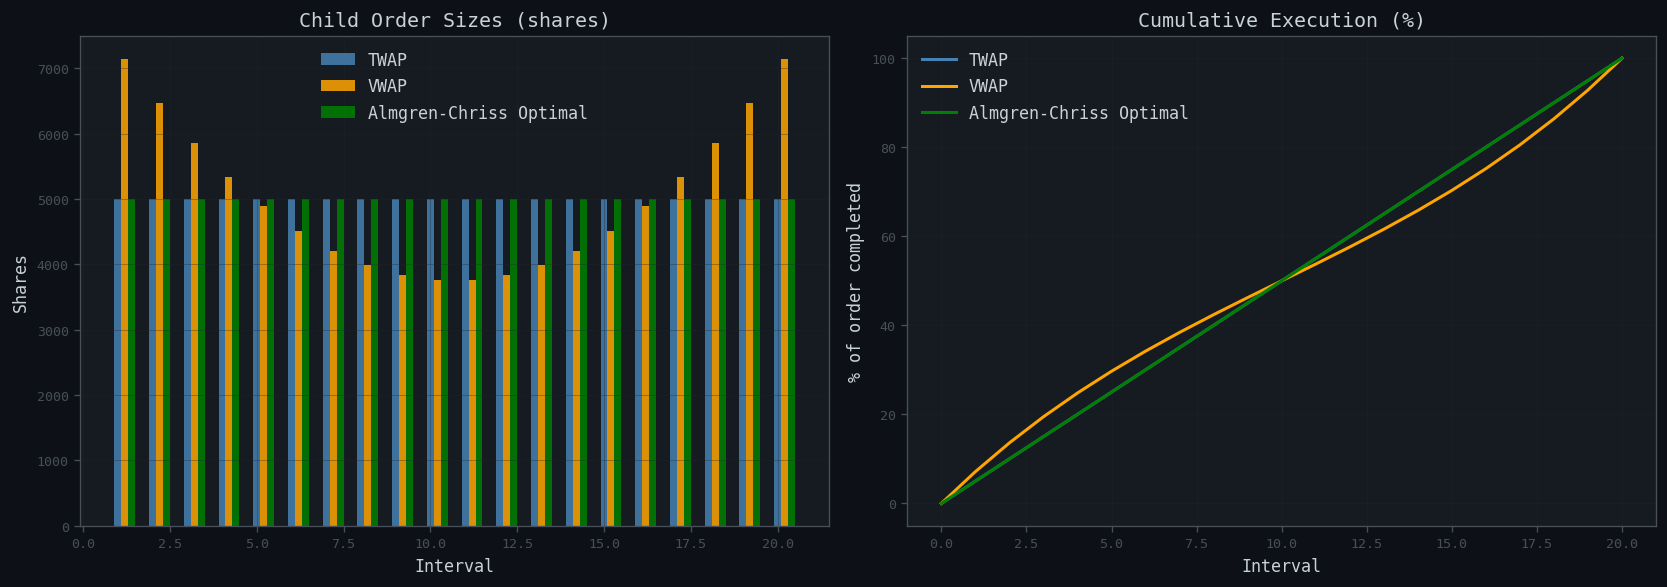

In [11]:
palette = ["steelblue", "orange", "green"]
intervals = np.arange(1, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (s, col) in enumerate(zip(schedules, palette)):
    axes[0].bar(intervals + i * 0.2, s.trades, width=0.2, color=col, alpha=0.85, label=s.name)
axes[0].set_title("Child Order Sizes (shares)")
axes[0].set_xlabel("Interval"); axes[0].set_ylabel("Shares")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

for s, col in zip(schedules, palette):
    cum = np.concatenate([[0], np.cumsum(s.trades) / s.total_shares * 100])
    axes[1].plot(np.arange(N + 1), cum, color=col, lw=1.8, label=s.name)
axes[1].set_title("Cumulative Execution (%)")
axes[1].set_xlabel("Interval"); axes[1].set_ylabel("% of order completed")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

## 3. Monte Carlo — Implementation Shortfall

**Key points:**
- The simulator method is `.simulate(schedule)` — **not** `.run()`
- `tau` must be passed to `ExecutionSimulator`
- IS attributes: `mean_is`, `std_is`, `var_95`, `cvar_95`, `mean_perm_impact`, `mean_temp_impact`, `mean_timing_risk`
- Convenience properties in bps: `mean_is_bps`, `std_is_bps`

In [12]:
sim = ExecutionSimulator(
    sigma=sigma, eta=eta, gamma=gamma,
    tau=tau, arrival_price=arrival_price, n_paths=10_000,
)

# .simulate() — not .run()
reports = [sim.simulate(s) for s in schedules]

print(f"{'Schedule':<20} {'E[IS] bps':>10} {'std[IS] bps':>12} {'VaR 95% bps':>12}")
print("-" * 58)
for rep in reports:
    var_bps = rep.var_95 / arrival_price * 1e4
    print(f"{rep.schedule_name:<20} {rep.mean_is_bps:>10.2f} {rep.std_is_bps:>12.2f} {var_bps:>12.2f}")

Schedule              E[IS] bps  std[IS] bps  VaR 95% bps
----------------------------------------------------------
TWAP                       2.64         0.89         4.11
VWAP                       2.76         0.87         4.20
Almgren-Chriss Optimal       2.64         0.89         4.11


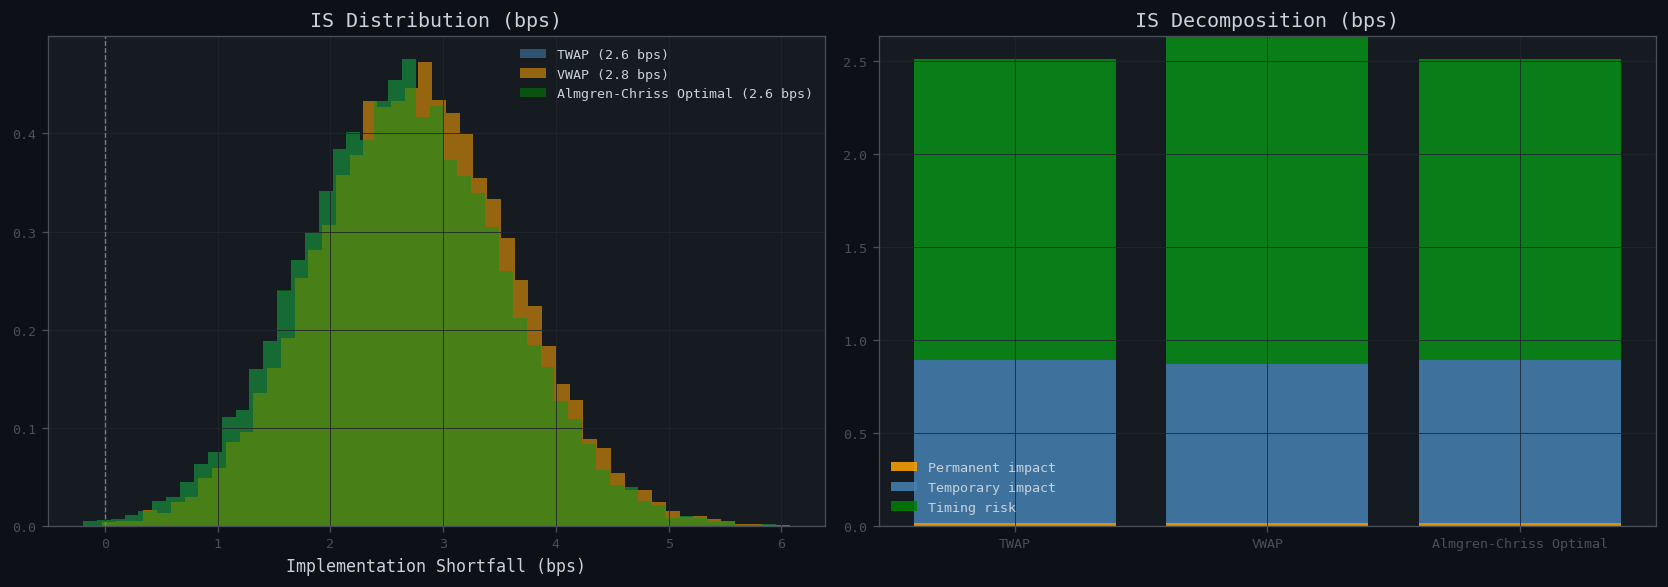

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IS distributions
for rep, col in zip(reports, palette):
    arr = rep.is_samples / arrival_price * 1e4
    axes[0].hist(arr, bins=50, density=True, color=col, alpha=0.55, edgecolor="none",
                 label=f"{rep.schedule_name} ({rep.mean_is_bps:.1f} bps)")
axes[0].axvline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("IS Distribution (bps)")
axes[0].set_xlabel("Implementation Shortfall (bps)"); axes[0].legend(fontsize=8)

# IS decomposition
names  = [rep.schedule_name for rep in reports]
perms  = [rep.mean_perm_impact  / arrival_price * 1e4 for rep in reports]
temps  = [rep.mean_temp_impact  / arrival_price * 1e4 for rep in reports]
timing = [rep.mean_timing_risk  / arrival_price * 1e4 for rep in reports]
xp = np.arange(len(names))

axes[1].bar(xp, perms,  color="orange",    alpha=0.85, label="Permanent impact")
axes[1].bar(xp, temps,  bottom=perms,       color="steelblue", alpha=0.85, label="Temporary impact")
axes[1].bar(xp, timing, bottom=np.array(perms) + np.array(temps),
            color="green", alpha=0.85, label="Timing risk")
axes[1].set_title("IS Decomposition (bps)")
axes[1].set_xticks(xp); axes[1].set_xticklabels(names); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Almgren–Chriss Efficient Frontier — E[IS] vs σ[IS] as λ Varies

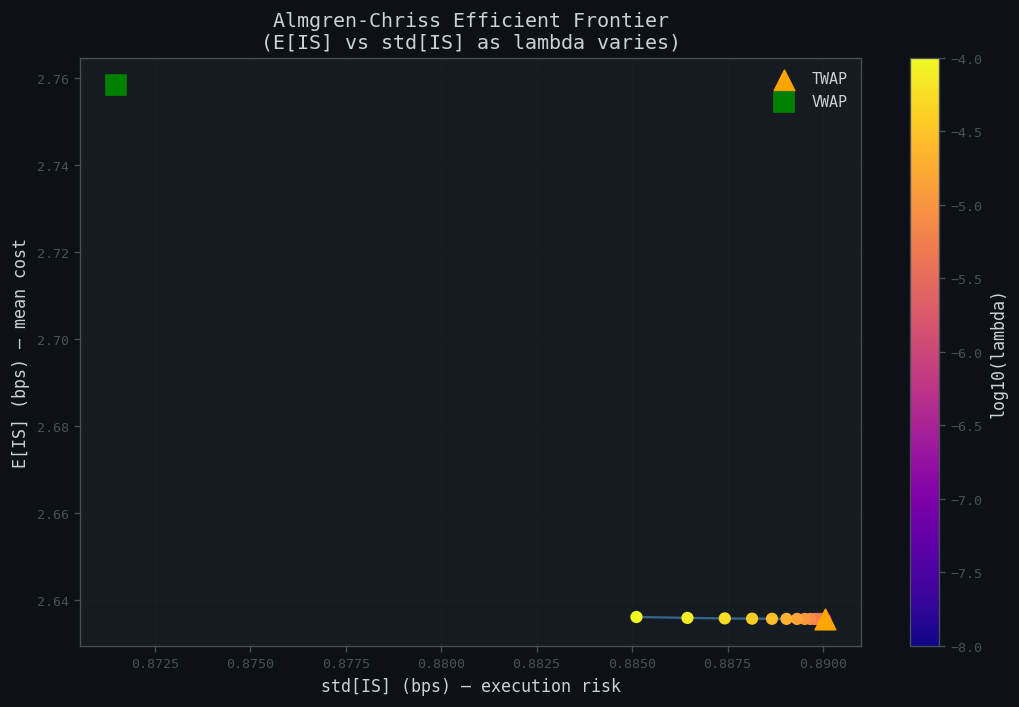

In [14]:
lambdas  = np.logspace(-8, -4, 30)
frontier = []
for lam_i in lambdas:
    s_i   = almgren_chriss(X, sigma=sigma, eta=eta, gamma=gamma, lam=lam_i, N=N, tau=tau)
    rep_i = sim.simulate(s_i)
    frontier.append({"lambda": lam_i, "mean_is": rep_i.mean_is_bps, "std_is": rep_i.std_is_bps})

stds  = [d["std_is"]  for d in frontier]
means = [d["mean_is"] for d in frontier]

plt.figure(figsize=(9, 6))
sc = plt.scatter(stds, means, c=np.log10(lambdas), cmap="plasma", s=40, zorder=5)
plt.plot(stds, means, color="steelblue", lw=1.4, alpha=0.7, zorder=4)
plt.colorbar(sc, label="log10(lambda)")

r_twap = reports[0]; r_vwap = reports[1]
plt.scatter(r_twap.std_is_bps, r_twap.mean_is_bps,
            color="orange", s=150, marker="^", zorder=6, label="TWAP")
plt.scatter(r_vwap.std_is_bps, r_vwap.mean_is_bps,
            color="green", s=150, marker="s", zorder=6, label="VWAP")

plt.xlabel("std[IS] (bps) — execution risk")
plt.ylabel("E[IS] (bps) — mean cost")
plt.title("Almgren-Chriss Efficient Frontier\n(E[IS] vs std[IS] as lambda varies)")
plt.legend(fontsize=9); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()